In [1]:
# Third party packages.
import os

import pandas as pd             # Data handling
import polars as pl             # Data handling ('Blazingly fast DataFrames'), alternative to Pandas.
import polars.selectors as cs   # Select columns of particular type.
import numpy as np              # Numeric calculations
import pickle                   # Save and load data
import seaborn as sns           # Visualize data
import matplotlib.pyplot as plt # Visualize data

from sklearn.model_selection    import train_test_split     # Split data
from sklearn.preprocessing      import StandardScaler       # Scale data
from sklearn.linear_model       import LinearRegression     # Linear regression
from sklearn.linear_model       import LassoCV              # Lasso regression
from sklearn.preprocessing      import OneHotEncoder        # One hot encoding
from sklearn.neighbors          import KNeighborsRegressor  # KNN regression
from sklearn.model_selection    import GridSearchCV         # Grid search

from scipy.stats import pearsonr # Correlation

In [6]:
# Load datasets
df_ogd =  pl.read_parquet(f'../Experiment/Knee/prepared_datasets/pipeline1_test.parquet')
df_mm = pl.read_parquet(f'../Experiment/Knee/prepared_datasets/pipeline2_median_mode_test.parquet')
df_mice = pl.read_parquet(f'../Experiment/Knee/prepared_datasets/pipeline3_mice_test.parquet')

In [7]:
df_ogd.columns

['Provider Code',
 'Procedure',
 'Revision Flag',
 'Year',
 'Age Band',
 'Gender',
 'Pre-Op Q Assisted',
 'Pre-Op Q Assisted By',
 'Pre-Op Q Symptom Period',
 'Pre-Op Q Previous Surgery',
 'Pre-Op Q Living Arrangements',
 'Pre-Op Q Disability',
 'Heart Disease',
 'High Bp',
 'Stroke',
 'Circulation',
 'Lung Disease',
 'Diabetes',
 'Kidney Disease',
 'Nervous System',
 'Liver Disease',
 'Cancer',
 'Depression',
 'Arthritis',
 'Pre-Op Q Mobility',
 'Pre-Op Q Self-Care',
 'Pre-Op Q Activity',
 'Pre-Op Q Discomfort',
 'Pre-Op Q Anxiety',
 'Knee Replacement Pre-Op Q Pain',
 'Knee Replacement Pre-Op Q Night Pain',
 'Knee Replacement Pre-Op Q Washing',
 'Knee Replacement Pre-Op Q Transport',
 'Knee Replacement Pre-Op Q Walking',
 'Knee Replacement Pre-Op Q Standing',
 'Knee Replacement Pre-Op Q Limping',
 'Knee Replacement Pre-Op Q Kneeling',
 'Knee Replacement Pre-Op Q Work',
 'Knee Replacement Pre-Op Q Confidence',
 'Knee Replacement Pre-Op Q Shopping',
 'Knee Replacement Pre-Op Q Stairs',


In [8]:
# Variables to compare
vars_to_compare = [
    'health_gain',
    'Age Band',
    'Gender',
    'Revision Flag',
    'Procedure',
    # Pre-Op Q variables
    'Pre-Op Q Assisted','Pre-Op Q Assisted By','Pre-Op Q Symptom Period',
    'Pre-Op Q Previous Surgery','Pre-Op Q Living Arrangements','Pre-Op Q Disability',
    'Pre-Op Q Mobility','Pre-Op Q Self-Care','Pre-Op Q Activity',
    'Pre-Op Q Discomfort','Pre-Op Q Anxiety',
    # Knee-specific Pre-Op Q variables
    'Knee Replacement Pre-Op Q Pain','Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing','Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking','Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping','Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work','Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping','Knee Replacement Pre-Op Q Stairs',
    # Comorbidities
    'Heart Disease','High Bp','Stroke','Circulation','Lung Disease','Diabetes',
    'Kidney Disease','Nervous System','Liver Disease','Cancer','Depression','Arthritis'
]

# Select only relevant columns
df_ogd  = df_ogd.select(vars_to_compare)
df_mm   = df_mm.select(vars_to_compare)
df_mice = df_mice.select(vars_to_compare)

In [10]:
# --- Missingness comparison ---

# Count missing values in each dataset
missing_ogd = (
    df_ogd.null_count()
    .melt(variable_name="variable", value_name="missing_ogd")
)

missing_mm = (
    df_mm.null_count()
    .melt(variable_name="variable", value_name="missing_mm")
)

missing_mice = (
    df_mice.null_count()
    .melt(variable_name="variable", value_name="missing_mice")
)

# Join results side-by-side
missing_compare = missing_ogd.join(missing_mm, on="variable").join(missing_mice, on="variable")

print("=== Missingness Comparison ===")
print(missing_compare)

# --- Scrollable table ---
from IPython.display import HTML

HTML(f"""
<div style="height:400px; overflow:auto; border:1px solid #ccc; padding:10px;">
    {missing_compare.to_pandas().to_html(index=False)}
</div>
""")


C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\1815470690.py:6: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="variable", value_name="missing_ogd")
C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\1815470690.py:11: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="variable", value_name="missing_mm")
C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\1815470690.py:16: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="variable", value_name="missing_mice")


=== Missingness Comparison ===
shape: (40, 4)
┌────────────────┬─────────────┬────────────┬──────────────┐
│ variable       ┆ missing_ogd ┆ missing_mm ┆ missing_mice │
│ ---            ┆ ---         ┆ ---        ┆ ---          │
│ str            ┆ u32         ┆ u32        ┆ u32          │
╞════════════════╪═════════════╪════════════╪══════════════╡
│ health_gain    ┆ 0           ┆ 0          ┆ 0            │
│ Age Band       ┆ 1805        ┆ 0          ┆ 0            │
│ Gender         ┆ 1805        ┆ 0          ┆ 0            │
│ Revision Flag  ┆ 0           ┆ 0          ┆ 0            │
│ Procedure      ┆ 0           ┆ 0          ┆ 0            │
│ …              ┆ …           ┆ …          ┆ …            │
│ Nervous System ┆ 0           ┆ 0          ┆ 0            │
│ Liver Disease  ┆ 0           ┆ 0          ┆ 0            │
│ Cancer         ┆ 0           ┆ 0          ┆ 0            │
│ Depression     ┆ 0           ┆ 0          ┆ 0            │
│ Arthritis      ┆ 0           ┆ 0     

variable,missing_ogd,missing_mm,missing_mice
health_gain,0,0,0
Age Band,1805,0,0
Gender,1805,0,0
Revision Flag,0,0,0
Procedure,0,0,0
Pre-Op Q Assisted,268,0,0
Pre-Op Q Assisted By,0,0,0
Pre-Op Q Symptom Period,195,0,0
Pre-Op Q Previous Surgery,178,0,0
Pre-Op Q Living Arrangements,333,0,0


In [12]:
# --- Identify numeric and categorical variables ---
numeric_vars = [
    'health_gain',
    'Pre-Op Q Assisted','Pre-Op Q Assisted By','Pre-Op Q Symptom Period',
    'Pre-Op Q Previous Surgery','Pre-Op Q Living Arrangements','Pre-Op Q Disability',
    'Pre-Op Q Mobility','Pre-Op Q Self-Care','Pre-Op Q Activity',
    'Pre-Op Q Discomfort','Pre-Op Q Anxiety',
    'Knee Replacement Pre-Op Q Pain','Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing','Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking','Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping','Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work','Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping','Knee Replacement Pre-Op Q Stairs'
]

categorical_vars = [
    'Age Band','Gender','Revision Flag','Procedure',
    'Heart Disease','High Bp','Stroke','Circulation','Lung Disease','Diabetes',
    'Kidney Disease','Nervous System','Liver Disease','Cancer','Depression','Arthritis'
]

In [15]:
# --- Summary statistics for numeric variables ---

stats_ogd = df_ogd.select(
    [
        pl.col(v).mean().alias(f"{v}_mean_ogd")
        for v in numeric_vars
    ] + [
        pl.col(v).std().alias(f"{v}_std_ogd")
        for v in numeric_vars
    ] + [
        pl.col(v).median().alias(f"{v}_median_ogd")
        for v in numeric_vars
    ]
)

stats_mm = df_mm.select(
    [
        pl.col(v).mean().alias(f"{v}_mean_mm")
        for v in numeric_vars
    ] + [
        pl.col(v).std().alias(f"{v}_std_mm")
        for v in numeric_vars
    ] + [
        pl.col(v).median().alias(f"{v}_median_mm")
        for v in numeric_vars
    ]
)

stats_mice = df_mice.select(
    [
        pl.col(v).mean().alias(f"{v}_mean_mice")
        for v in numeric_vars
    ] + [
        pl.col(v).std().alias(f"{v}_std_mice")
        for v in numeric_vars
    ] + [
        pl.col(v).median().alias(f"{v}_median_mice")
        for v in numeric_vars
    ]
)

print("=== Numeric Summary Statistics: OGD ===")
print(stats_ogd)

print("=== Numeric Summary Statistics: MM ===")
print(stats_mm)

print("=== Numeric Summary Statistics: MICE ===")
print(stats_mice)


=== Numeric Summary Statistics: OGD ===
shape: (1, 72)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ health_ga ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ … ┆ Knee Repl ┆ Knee Repl ┆ Knee Repl ┆ Knee Rep │
│ in_mean_o ┆ Assisted_ ┆ Assisted  ┆ Symptom   ┆   ┆ acement   ┆ acement   ┆ acement   ┆ lacement │
│ gd        ┆ mean_ogd  ┆ By_mean_o ┆ Period_me ┆   ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q │
│ ---       ┆ ---       ┆ gd        ┆ an_o…     ┆   ┆ Work…     ┆ Conf…     ┆ Shop…     ┆ Stai…    │
│ f32       ┆ f64       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 16.869078 ┆ 1.848706  ┆ 1.0       ┆ 2.597515  ┆ … ┆ 1.0       ┆ 2.0       ┆ 2.0       ┆ 2.0      │
└───────────┴───────────┴───────────

In [16]:
# --- Simple value counts for categorical variables ---

for col in categorical_vars:
    print(f"\n=== Value Counts for {col} ===")
    
    print("OGD:")
    print(df_ogd[col].value_counts())
    
    print("MM:")
    print(df_mm[col].value_counts())
    
    print("MICE:")
    print(df_mice[col].value_counts())


=== Value Counts for Age Band ===
OGD:
shape: (7, 2)
┌──────────┬───────┐
│ Age Band ┆ count │
│ ---      ┆ ---   │
│ f64      ┆ u32   │
╞══════════╪═══════╡
│ 6.0      ┆ 4     │
│ 4.0      ┆ 10297 │
│ 2.0      ┆ 2583  │
│ null     ┆ 1805  │
│ 5.0      ┆ 2955  │
│ 3.0      ┆ 8501  │
│ 1.0      ┆ 46    │
└──────────┴───────┘
MM:
shape: (6, 2)
┌──────────┬───────┐
│ Age Band ┆ count │
│ ---      ┆ ---   │
│ f64      ┆ u32   │
╞══════════╪═══════╡
│ 1.0      ┆ 46    │
│ 2.0      ┆ 2583  │
│ 5.0      ┆ 2955  │
│ 4.0      ┆ 12102 │
│ 6.0      ┆ 4     │
│ 3.0      ┆ 8501  │
└──────────┴───────┘
MICE:
shape: (1_811, 2)
┌──────────┬───────┐
│ Age Band ┆ count │
│ ---      ┆ ---   │
│ f64      ┆ u32   │
╞══════════╪═══════╡
│ 3.612893 ┆ 1     │
│ 3.418806 ┆ 1     │
│ 3.563893 ┆ 1     │
│ 4.402919 ┆ 1     │
│ 3.824279 ┆ 1     │
│ …        ┆ …     │
│ 3.192027 ┆ 1     │
│ 3.11742  ┆ 1     │
│ 3.622977 ┆ 1     │
│ 3.334579 ┆ 1     │
│ 3.229834 ┆ 1     │
└──────────┴───────┘

=== Value Counts for 

=== Summary Statistics: OGD ===
shape: (1, 120)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ health_ga ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ … ┆ Knee Repl ┆ Knee Repl ┆ Knee Repl ┆ Knee Rep │
│ in_mean_m ┆ Assisted_ ┆ Assisted  ┆ Symptom   ┆   ┆ acement   ┆ acement   ┆ acement   ┆ lacement │
│ anu       ┆ mean_manu ┆ By_mean_m ┆ Period_me ┆   ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q │
│ ---       ┆ ---       ┆ anu       ┆ an_m…     ┆   ┆ Work…     ┆ Conf…     ┆ Shop…     ┆ Stai…    │
│ f32       ┆ f64       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 16.869078 ┆ 1.848706  ┆ 1.0       ┆ 2.597515  ┆ … ┆ 2.0       ┆ 3.0       ┆ 3.0       ┆ 2.0      │
└───────────┴───────────┴───────────┴──────

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


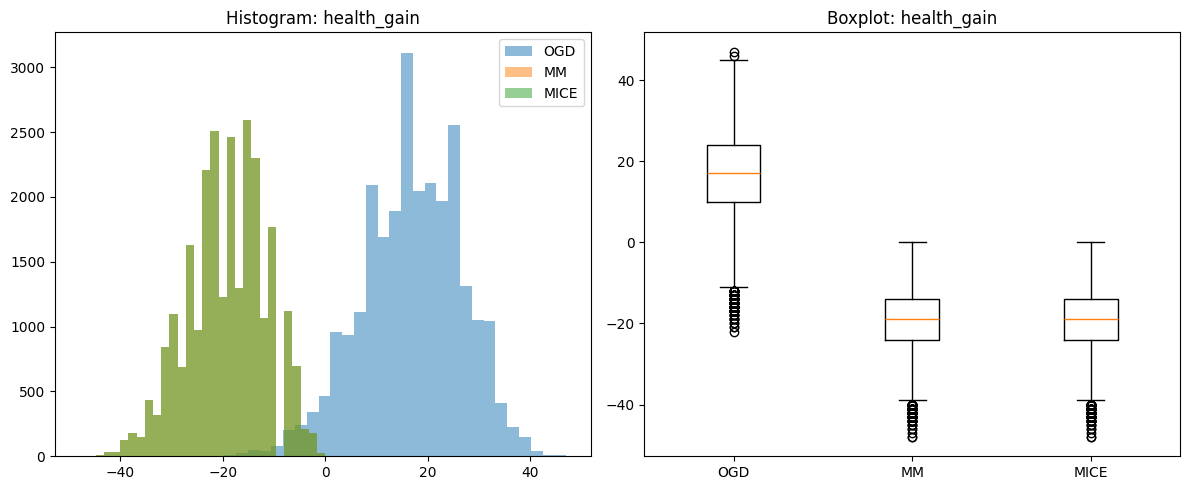

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


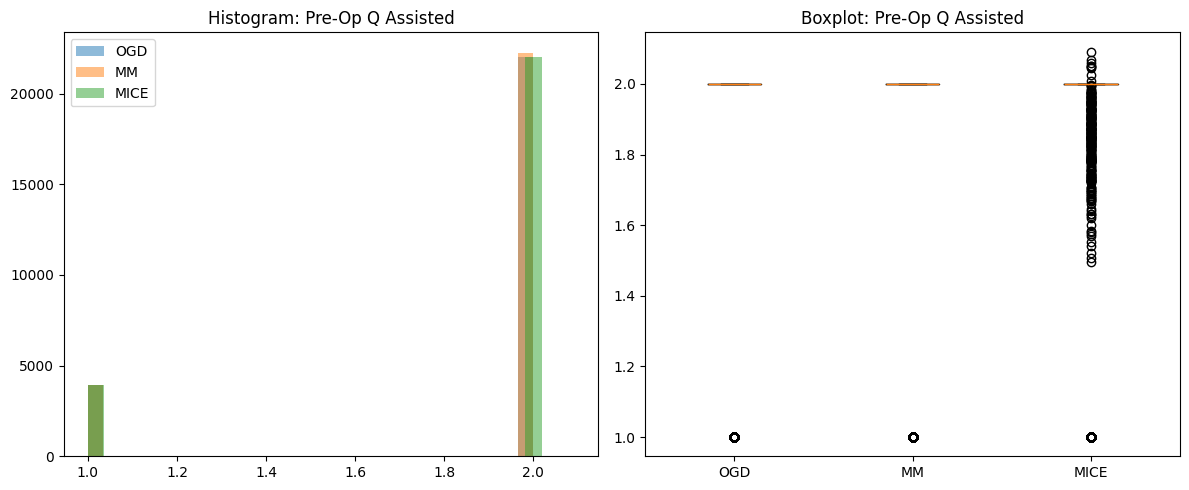

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


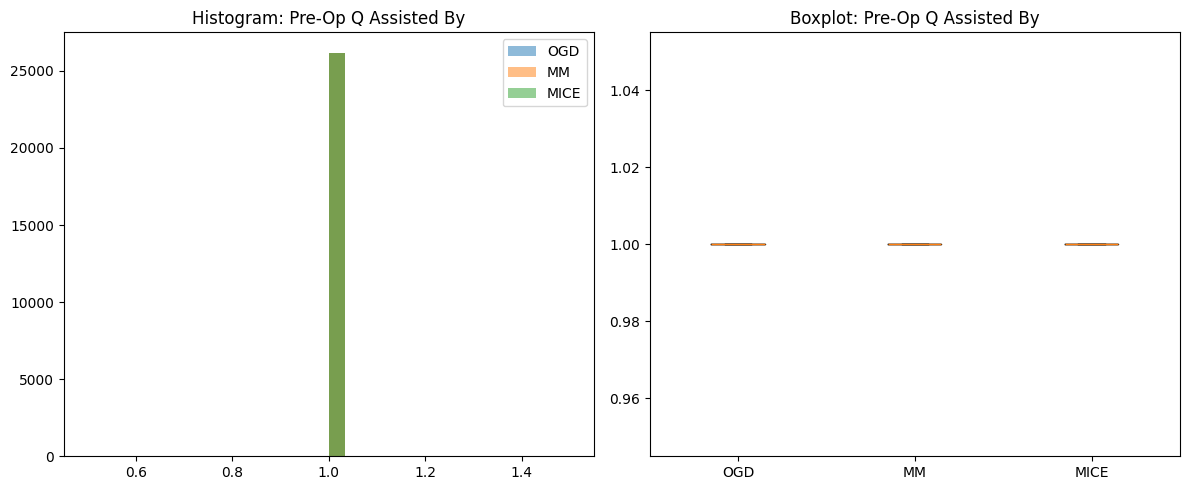

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


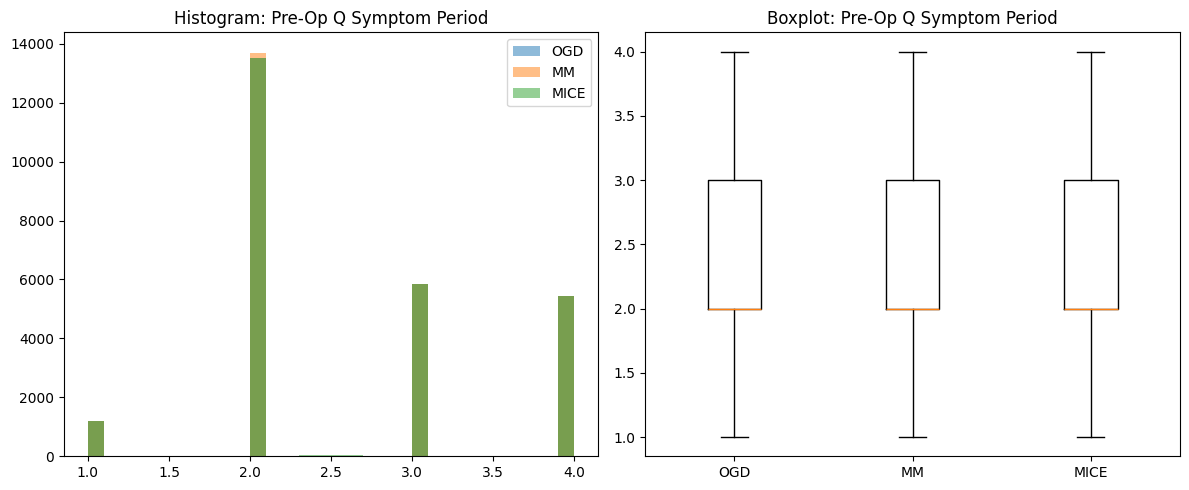

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


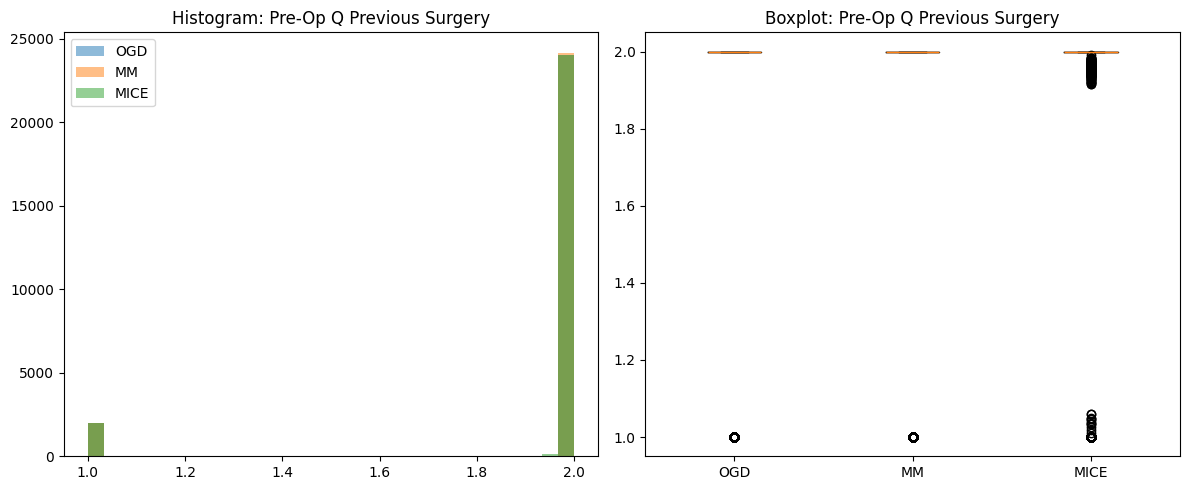

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


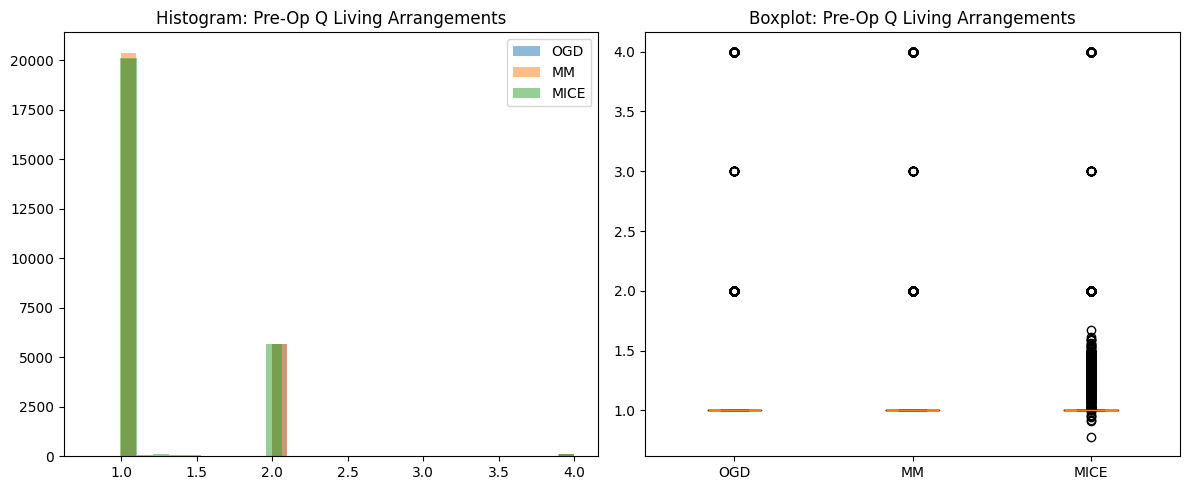

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


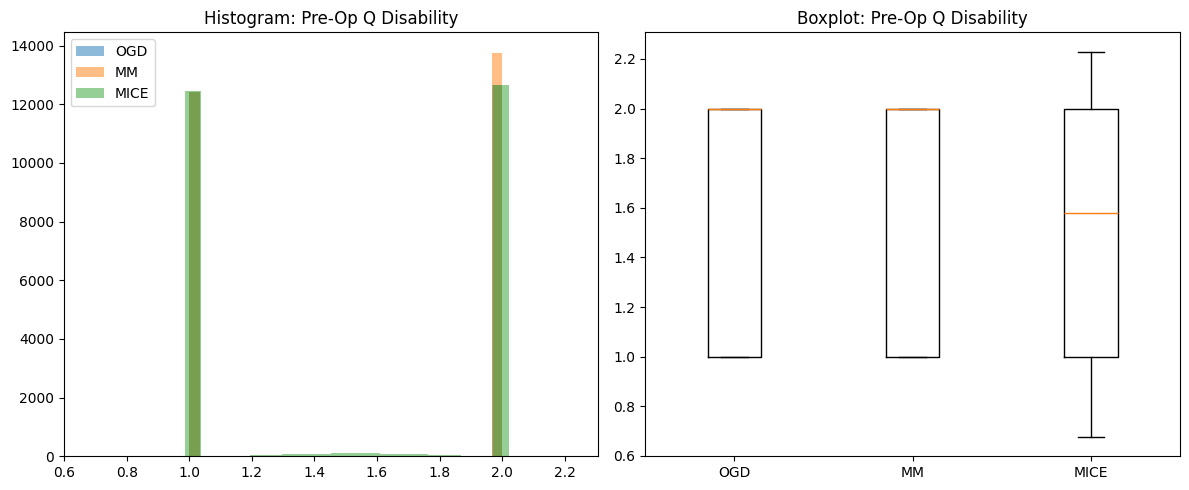

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


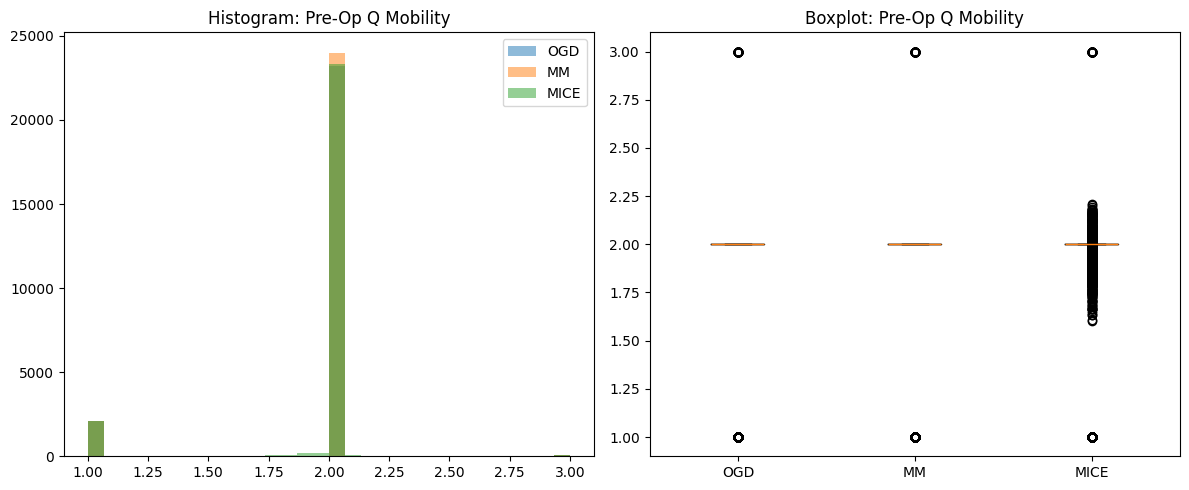

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


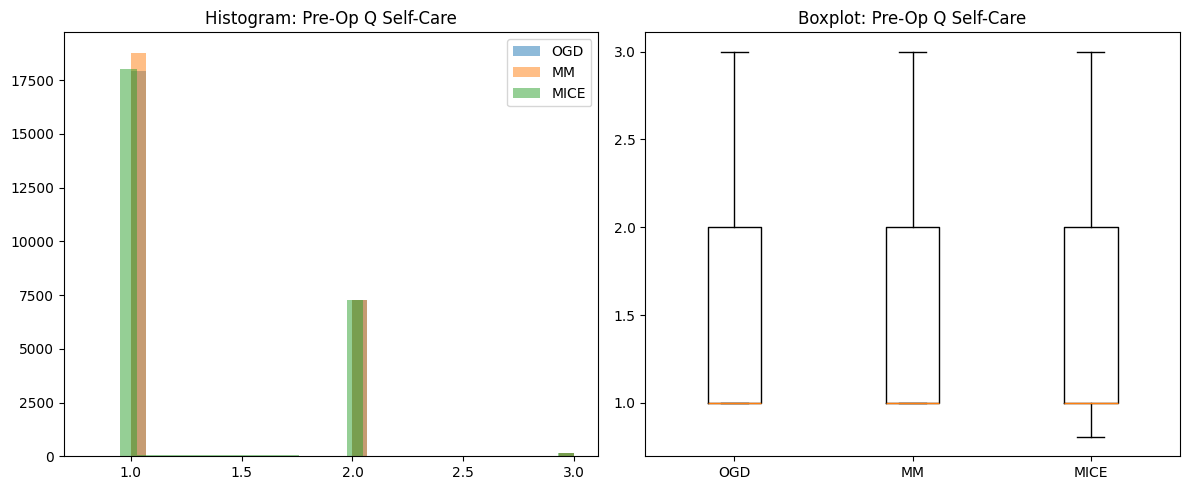

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


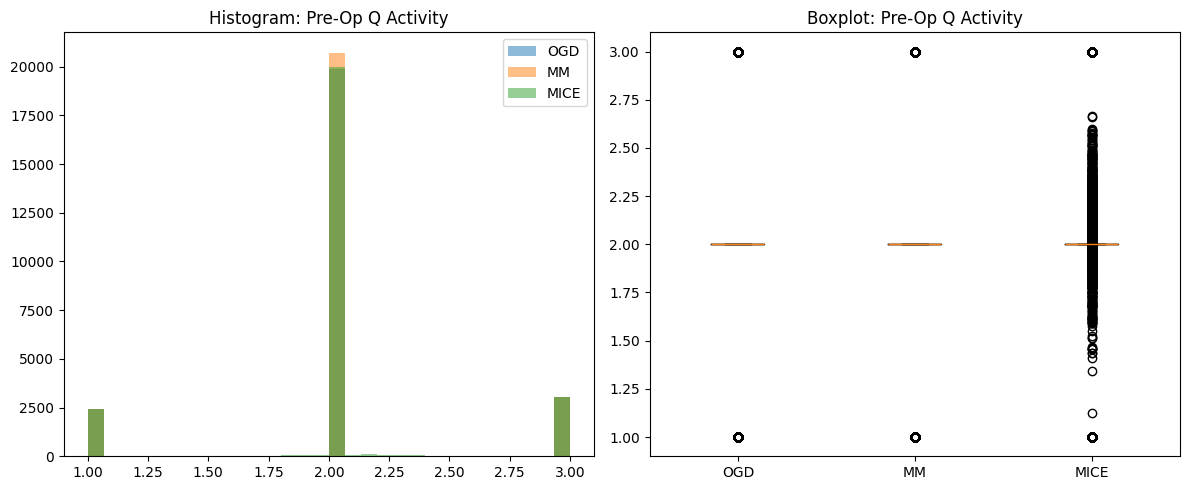

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


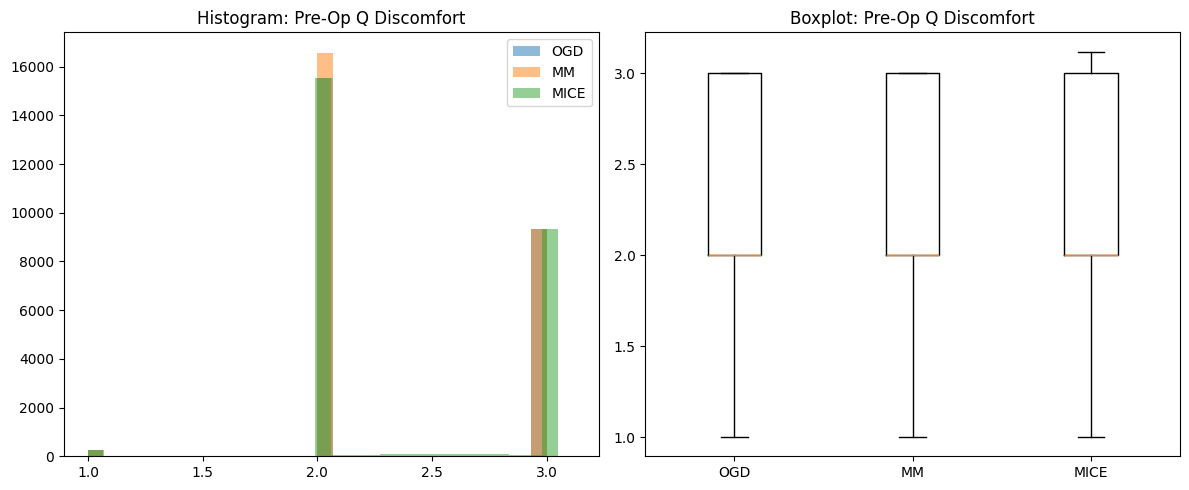

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


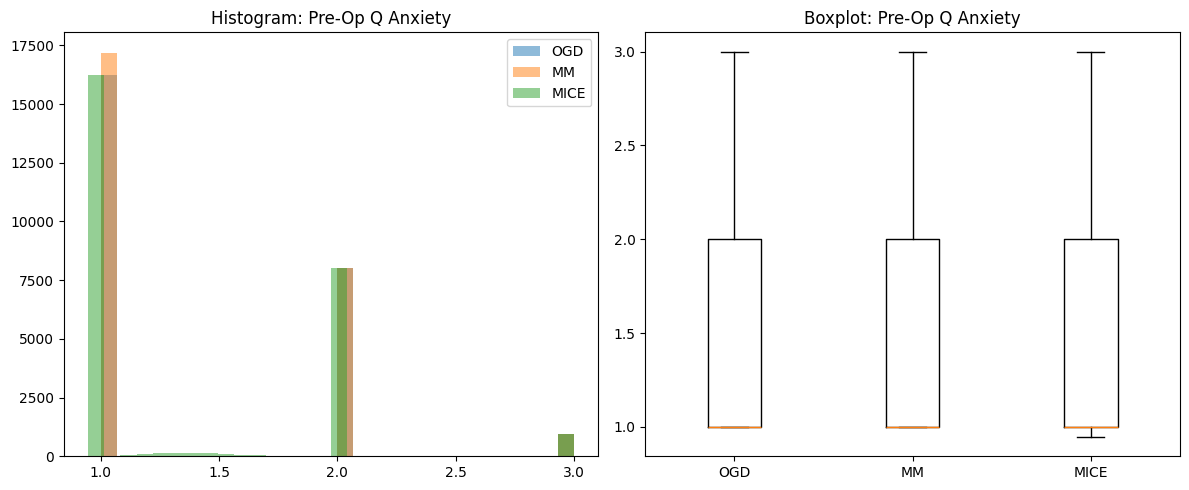

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


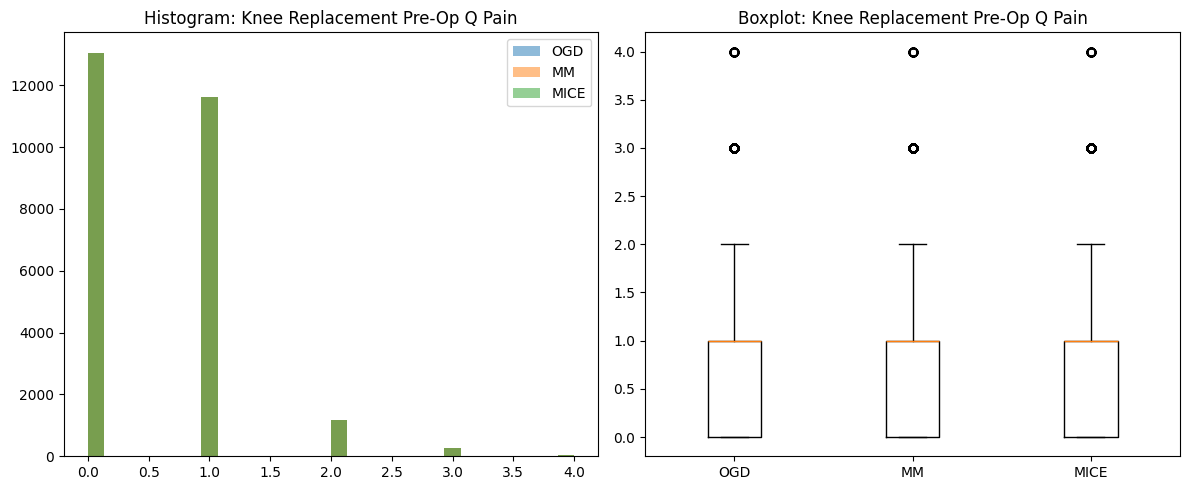

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


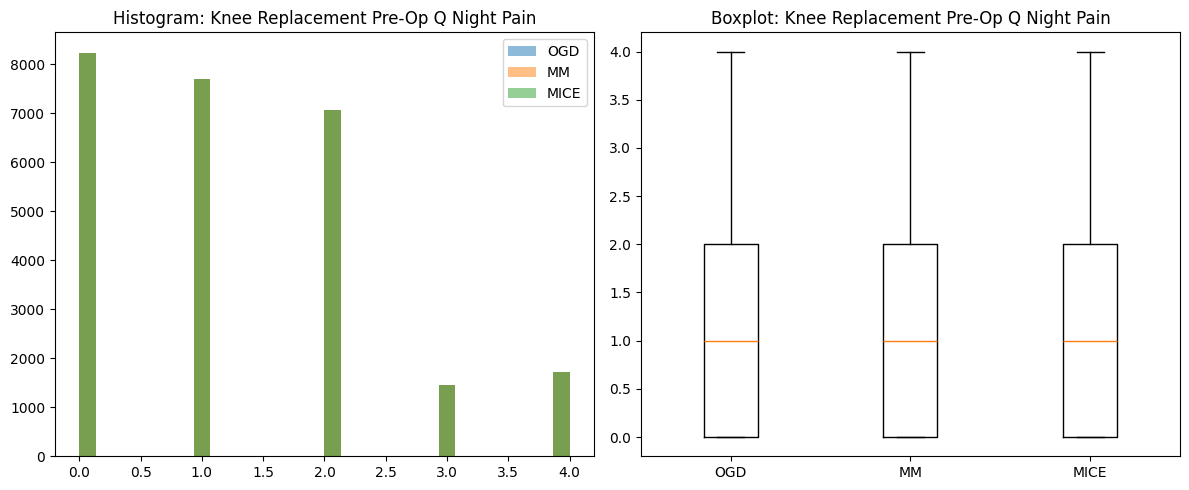

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


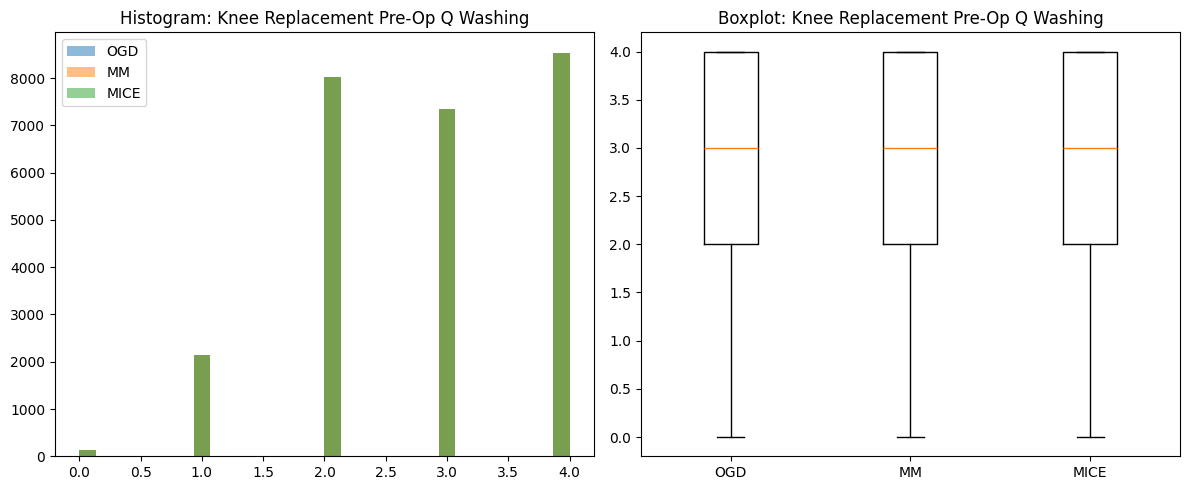

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


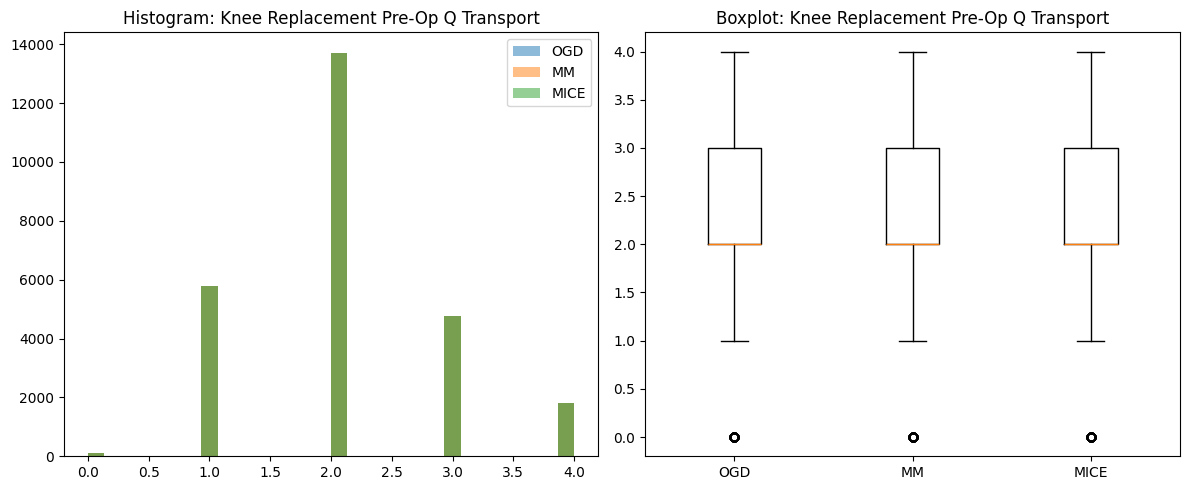

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


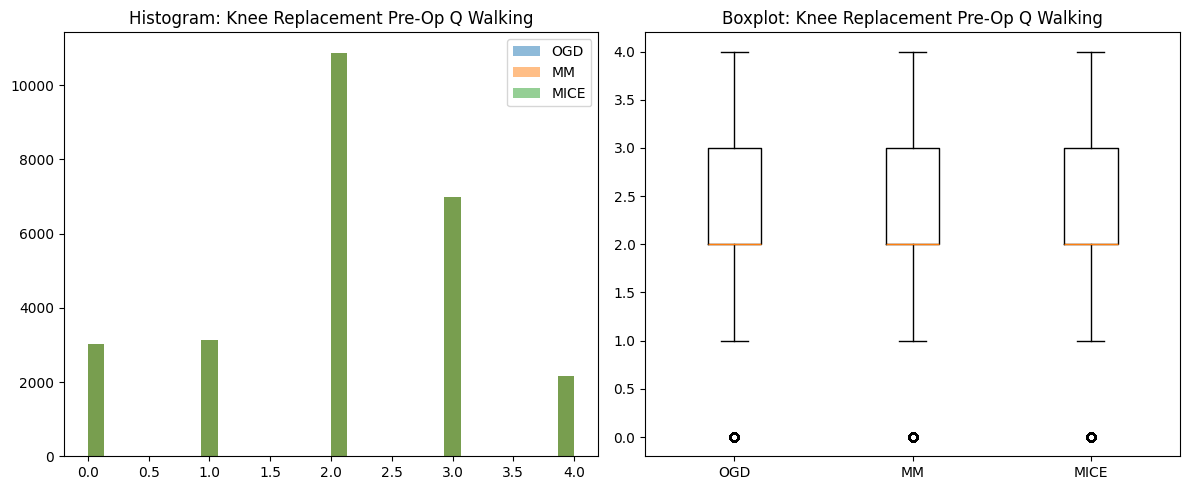

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


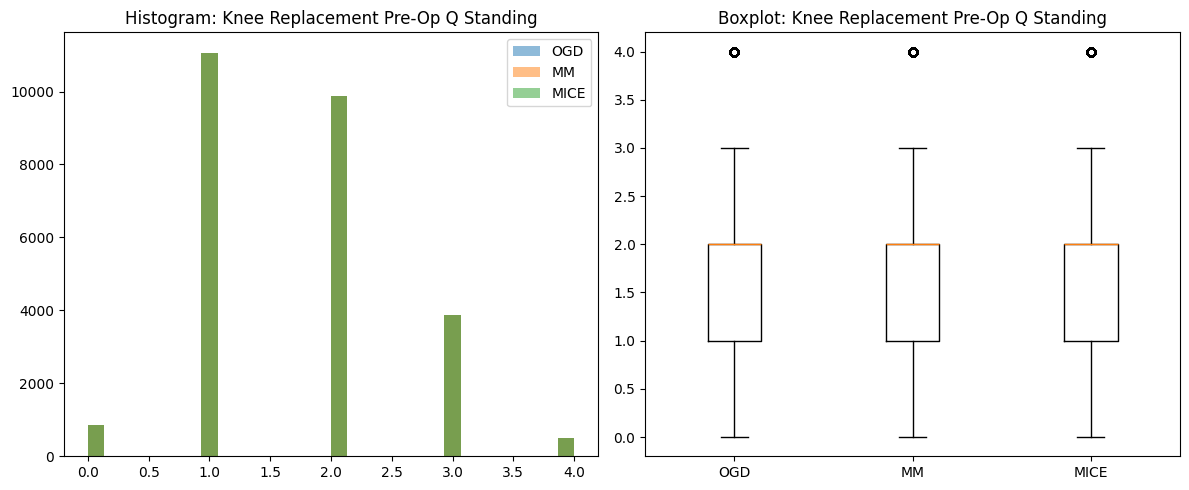

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


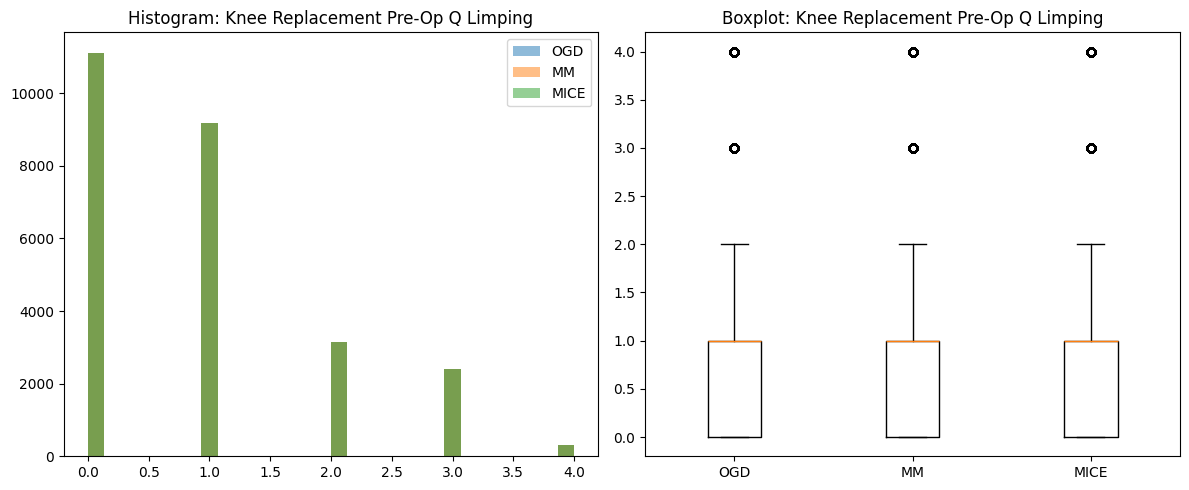

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


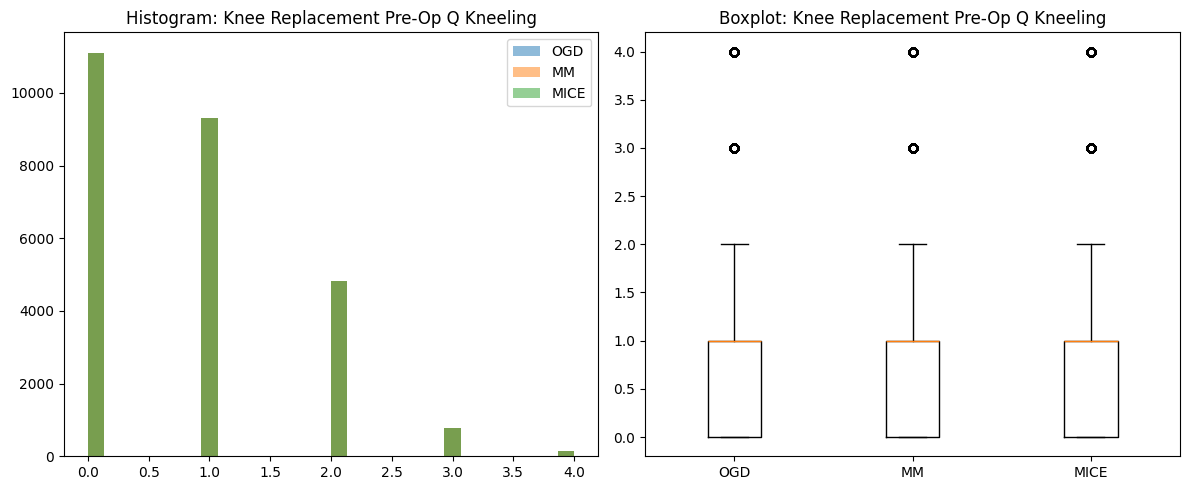

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


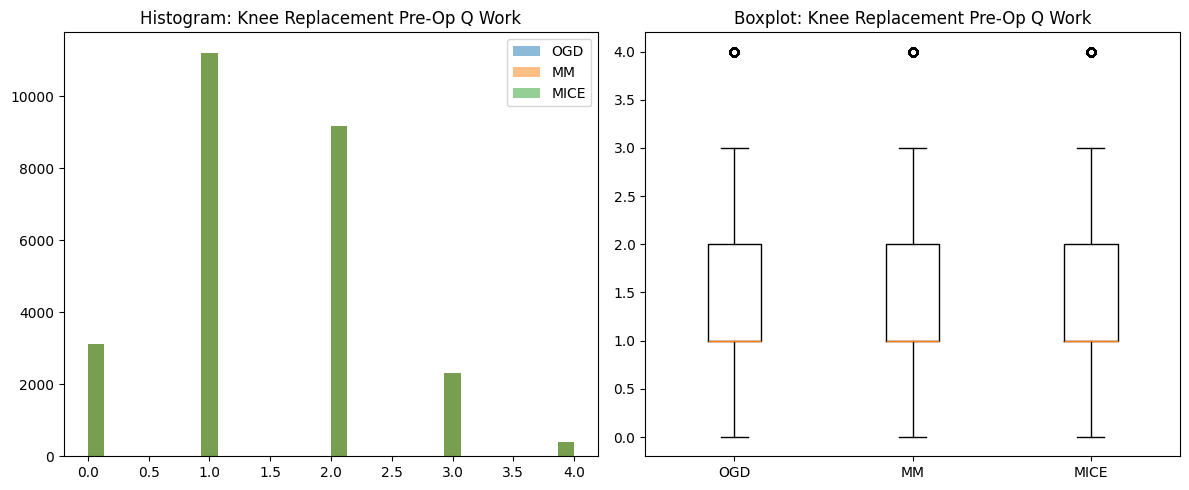

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


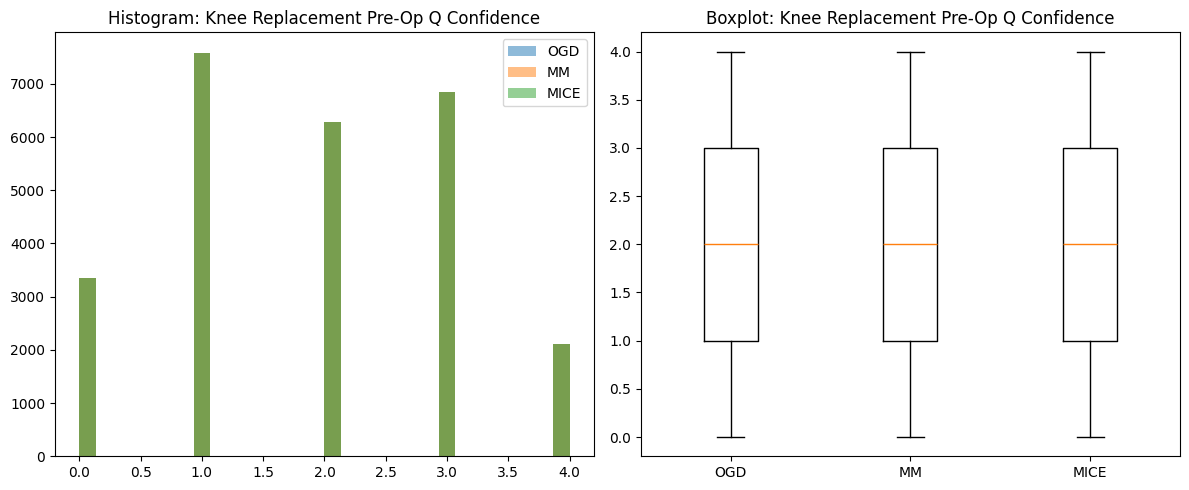

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


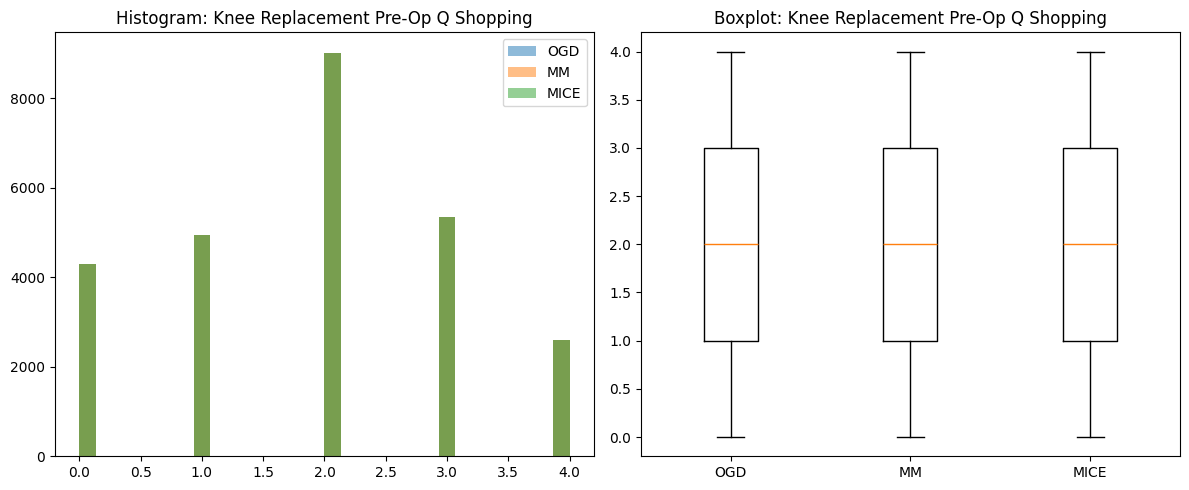

C:\Users\jkrin\AppData\Local\Temp\ipykernel_8536\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


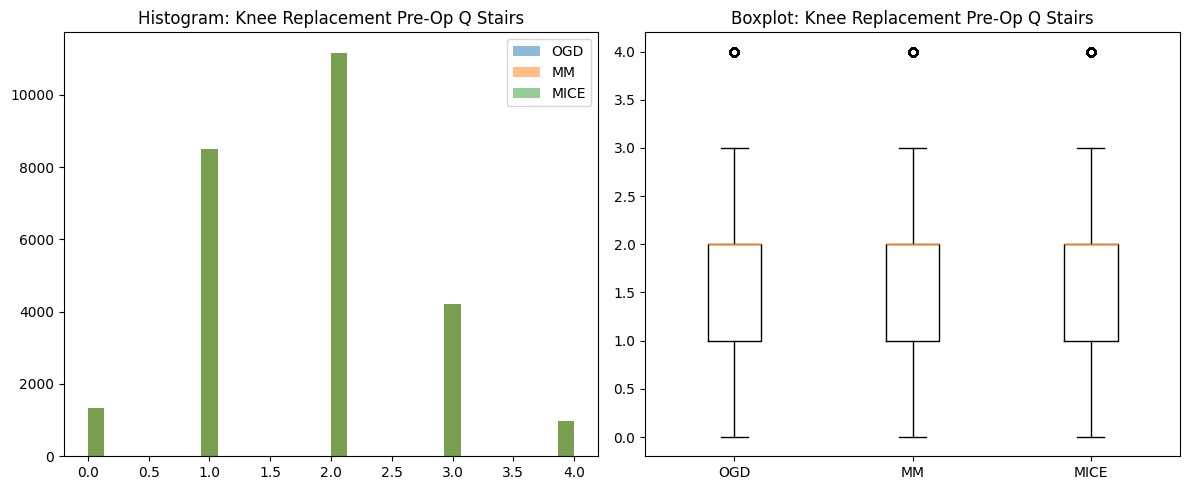

In [18]:

import polars as pl
import matplotlib.pyplot as plt

# Key numeric variables
key_numeric_vars = [
    'health_gain',
    'Pre-Op Q Assisted','Pre-Op Q Assisted By','Pre-Op Q Symptom Period',
    'Pre-Op Q Previous Surgery','Pre-Op Q Living Arrangements','Pre-Op Q Disability',
    'Pre-Op Q Mobility','Pre-Op Q Self-Care','Pre-Op Q Activity',
    'Pre-Op Q Discomfort','Pre-Op Q Anxiety',
    'Knee Replacement Pre-Op Q Pain','Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing','Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking','Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping','Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work','Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping','Knee Replacement Pre-Op Q Stairs'
]

# --- Summary statistics table ---
stats_manu = df_ogd.select(
    [pl.col(v).mean().alias(f"{v}_mean_manu") for v in key_numeric_vars] +
    [pl.col(v).median().alias(f"{v}_median_manu") for v in key_numeric_vars] +
    [pl.col(v).std().alias(f"{v}_std_manu") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.25).alias(f"{v}_q25_manu") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.75).alias(f"{v}_q75_manu") for v in key_numeric_vars]
)

stats_mm = df_mm.select(
    [pl.col(v).mean().alias(f"{v}_mean_mm") for v in key_numeric_vars] +
    [pl.col(v).median().alias(f"{v}_median_mm") for v in key_numeric_vars] +
    [pl.col(v).std().alias(f"{v}_std_mm") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.25).alias(f"{v}_q25_mm") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.75).alias(f"{v}_q75_mm") for v in key_numeric_vars]
)

stats_mice = df_mice.select(
    [pl.col(v).mean().alias(f"{v}_mean_mice") for v in key_numeric_vars] +
    [pl.col(v).median().alias(f"{v}_median_mice") for v in key_numeric_vars] +
    [pl.col(v).std().alias(f"{v}_std_mice") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.25).alias(f"{v}_q25_mice") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.75).alias(f"{v}_q75_mice") for v in key_numeric_vars]
)

print("=== Summary Statistics: OGD ===")
print(stats_manu)

print("\n=== Summary Statistics: MM ===")
print(stats_mm)

print("\n=== Summary Statistics: MICE ===")
print(stats_mice)


# --- Visual comparison: histograms + boxplots ---
for col in key_numeric_vars:
    ogd_vals = df_ogd[col].drop_nulls().to_numpy()
    mm_vals = df_mm[col].drop_nulls().to_numpy()    
    mice_vals = df_mice[col].drop_nulls().to_numpy()

    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(ogd_vals, bins=30, alpha=0.5, label="OGD")
    plt.hist(mm_vals, bins=30, alpha=0.5, label="MM")
    plt.hist(mice_vals, bins=30, alpha=0.5, label="MICE")
    plt.title(f"Histogram: {col}")
    plt.legend()

    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])
    plt.title(f"Boxplot: {col}")

    plt.tight_layout()
    plt.show()
